# Locally running portfolio-analysis streamlit app

## Modifications to make it a streamlit app

The first thing we will need to do is to slightly modify our app to transform it into a streamlit app as we previously did for our Two Agent Stand Up Comedy app. This process is quite straightforward, these are the modification we will need to do:

1. Import streamlit at the beginning of the script:
```python
import streamlit as st
```
2. Ask the user to write the tickers they'd like to analyze in a text field and add a button that will trigger the app:
```python
assets = st.text_input("Assets you want to analyze (provide the tickers)?")
hit_button = st.button('Start analysis')
```
3. Replace a string variable called `assets` in the `financial_tasks` prompt with tickers provided in the text field once the user hits the button:
```python
if hit_button is True:

    financial_tasks = [
    f"""Today is the {date_str}. 
    What are the current stock prices of {stocks}, and how is the performance over the past 6 months in terms of percentage change? 
    Start by retrieving the full name of each stock and use it for all future requests.
    Prepare a figure of the normalized price of these stocks and save it to a file named normalized_prices.png. Include information about, if applicable: 
    * P/E ratio
    * Forward P/E
    * Dividends
    * Price to book
    * Debt/Eq
    * ROE
    * Analyze the correlation between the stocks
    Do not use a solution that requires an API key.
    If some of the data does not makes sense, such as a price of 0, change the query and re-try.""",

    """Investigate possible reasons of the stock performance leveraging market news headlines from Bing News or Google Search. Retrieve news headlines using python and return them. Use the full name stocks to retrieve headlines. Retrieve at least 10 headlines per stock. Do not use a solution that requires an API key. Do not perform a sentiment analysis.""",
]
```
4. We will also add a spinner that will let the user know that the chat is ongoing:
```python
    with st.spinner("Agents working on the analysis...."):
        chat_results = autogen.initiate_chats(
            
        ... # main chat flow
            
        )
```
5. At the very end of the code, once the agents have finished chatting, we will present the results. We will show the image that was generated and will present the markdown blogpost by choosing the last message in the chat conversation:
```python
    st.image("./coding/normalized_prices.png")
    st.markdown(chat_results[-1].chat_history[-1]["content"])
```
6. Since we mainly want to show the blogpost on the streamlit webpage, we are going to remoev the last chat that aimed at exporting the blogpost in a `.md` file. We can thus also delete the Export agent definition.

## Run the streamlit portfolio-analysis app locally

You should now be able to run this streamlit app locally using the command:

`streamlit run P02-S06-02-Streamlit-financial_report.py`

Try it and ensure everything is working as planned!


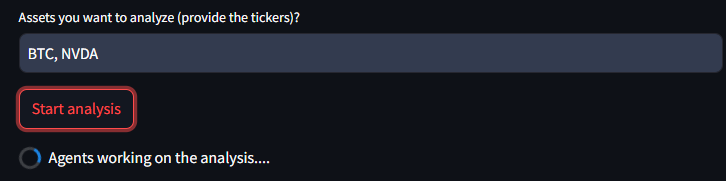
---
